# W05 — Model Build and Baseline Comparison

**Submission target:** `work/notebooks/w05_model.ipynb`

This notebook follows the assignment sequence:
1. Method choice and why
2. Split design
3. Train + compare vs Week-4 baseline
4. Errors and interpretation
5. Self-check

**Important:** the included CSV is demo data only so the notebook is executable. Replace it with the exact W04 data and baseline before final submission.


## 1. Method choice and why

For a supervised binary-classification lane, the notebook compares a simple baseline with Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

The model is selected using the agreed evaluation metric rather than complexity alone. Logistic Regression provides an interpretable low-complexity benchmark; tree models test nonlinear relationships; Random Forest reduces single-tree variance; Gradient Boosting is included as a stronger nonlinear candidate when appropriate.


## 2. Split design

Use the same evaluation split and primary metric as W04. If repeated observations belong to the same subject, device, customer, experiment, or other entity, use a group-aware split so the same group is not present in both training and evaluation data.

The final test/evaluation data should remain unseen during model fitting and tuning.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
DATA_PATH = Path("../../data/w04_data.csv")
TARGET = "target"
GROUP_COL = None  # Set to your real group column if needed


In [2]:
def make_demo_data(n=700, seed=42):
    rng = np.random.default_rng(seed)
    x1, x2, x3, x4 = [rng.normal(0, 1, n) for _ in range(4)]
    score = 1.3*x1 - 0.9*x2 + 0.6*x3 + 0.4*x4 + rng.normal(0, 0.9, n)
    y = (score > 0.35).astype(int)
    return pd.DataFrame({
        "feature_1": x1, "feature_2": x2,
        "feature_3": x3, "feature_4": x4, TARGET: y
    })

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    DATA_SOURCE = "W04 project data path"
else:
    df = make_demo_data()
    DATA_SOURCE = "DEMO DATA — replace before final submission"

assert TARGET in df.columns, f"Target column '{TARGET}' not found."
print("Data source:", DATA_SOURCE)
print("Shape:", df.shape)
display(df.head())


Data source: W04 project data path
Shape: (700, 5)


,feature_1,feature_2,feature_3,feature_4,target
0,0.304717,1.112966,1.182531,0.256659,0
1,-1.039984,-0.245061,-0.323985,-1.714486,0
2,0.750451,-1.030814,-0.204070,-0.713819,1
3,0.940565,-0.056955,-0.491656,0.771874,1
4,-1.951035,1.049174,-0.580651,-0.279677,0


In [3]:
# Signal and data-quality audit
numeric = df.select_dtypes(include=np.number)
display(numeric.corr(numeric_only=True)[[TARGET]].sort_values(TARGET, ascending=False))

print("Missingness:")
display(df.isna().mean().sort_values(ascending=False).head(10).to_frame("missing_rate"))


,target
target,1.000000
feature_1,0.543303
feature_3,0.254876
feature_4,0.206738
feature_2,-0.374046


Missingness:


,missing_rate
feature_1,0.0
feature_2,0.0
feature_3,0.0
feature_4,0.0
target,0.0


In [4]:
# Prepare X/y and choose a valid split
drop_cols = [TARGET]
if GROUP_COL and GROUP_COL in df.columns:
    drop_cols.append(GROUP_COL)

X = df.drop(columns=drop_cols).select_dtypes(include=np.number)
y = df[TARGET].astype(int)

if GROUP_COL and GROUP_COL in df.columns:
    groups = df[GROUP_COL]
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    split_name = "GroupShuffleSplit (80/20)"
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    split_name = "Stratified train/test split (80/20)"

print("Split:", split_name)
print("Train:", X_train.shape, "Test:", X_test.shape)


Split: Stratified train/test split (80/20)
Train: (560, 4) Test: (140, 4)


## 3. Train + compare vs the W04 baseline

The baseline in this executable template is a majority-class predictor. **For the real submission, replace this with the exact Week-4 baseline and keep the same evaluation rows and primary metric.**


In [5]:
from sklearn.base import clone

def metric_row(name, y_true, y_pred, y_prob=None):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None and len(np.unique(y_true)) == 2 else np.nan
    }

majority_class = int(y_train.mode()[0])
baseline_pred = np.full(len(y_test), majority_class)
results = [metric_row("W04 / majority baseline", y_test, baseline_pred)]


In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=3,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results.append(metric_row(name, y_test, pred, prob))
    fitted[name] = model

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df.round(4))


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.8500,0.8364,0.7931,0.8142,0.9437
1,Gradient Boosting,0.8286,0.8036,0.7759,0.7895,0.9039
2,Random Forest,0.8286,0.8269,0.7414,0.7818,0.9216
3,Decision Tree,0.7571,0.7400,0.6379,0.6852,0.8119
4,W04 / majority baseline,0.5857,0.0000,0.0000,0.0000,NaN


In [7]:
# Required model-vs-baseline comparison
baseline_f1 = results_df.loc[
    results_df["model"].str.contains("baseline", case=False), "f1"
].iloc[0]

comparison = results_df.copy()
comparison["f1_delta_vs_baseline"] = comparison["f1"] - baseline_f1

display(
    comparison[[
        "model", "f1", "f1_delta_vs_baseline",
        "accuracy", "precision", "recall", "roc_auc"
    ]].round(4)
)


,model,f1,f1_delta_vs_baseline,accuracy,precision,recall,roc_auc
0,Logistic Regression,0.8142,0.8142,0.8500,0.8364,0.7931,0.9437
1,Gradient Boosting,0.7895,0.7895,0.8286,0.8036,0.7759,0.9039
2,Random Forest,0.7818,0.7818,0.8286,0.8269,0.7414,0.9216
3,Decision Tree,0.6852,0.6852,0.7571,0.7400,0.6379,0.8119
4,W04 / majority baseline,0.0000,0.0000,0.5857,0.0000,0.0000,NaN


## 4. Errors and interpretation


In [8]:
best_name = results_df.iloc[0]["model"]
best_model = fitted.get(best_name)

if best_model is not None:
    best_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, best_pred)

    print("Selected model:", best_name)
    print("Confusion matrix:")
    display(pd.DataFrame(cm, index=["actual_0", "actual_1"],
                         columns=["pred_0", "pred_1"]))

    errors = X_test.copy()
    errors["actual"] = y_test.to_numpy()
    errors["predicted"] = best_pred
    errors = errors[errors["actual"] != errors["predicted"]]

    print("Number of test errors:", len(errors))
    display(errors.head(10))


Selected model: Logistic Regression
Confusion matrix:


,pred_0,pred_1
actual_0,73,9
actual_1,12,46


Number of test errors: 21


,feature_1,feature_2,feature_3,feature_4,actual,predicted
473,0.185326,-0.997852,-1.194365,0.182915,0,1
572,0.262036,-0.374945,0.104690,-0.464380,0,1
199,-0.163443,-1.535642,-1.067594,-0.306119,0,1
330,1.511228,1.187634,-0.090871,-1.522199,1,0
653,-1.103741,0.352627,2.857438,0.113875,1,0
628,-1.040586,-0.123809,0.205411,1.841256,1,0
187,-1.224469,-0.431339,0.942766,2.277430,1,0
279,0.262749,0.443813,-0.280600,-0.086705,1,0
438,-0.654283,-0.088796,1.478279,0.614440,1,0
197,-0.394605,-0.862318,0.238601,-0.750002,1,0


,feature,importance_mean,importance_std
0,feature_1,0.2343,0.0370
1,feature_2,0.1448,0.0287
3,feature_4,0.0757,0.0232
2,feature_3,0.0586,0.0317


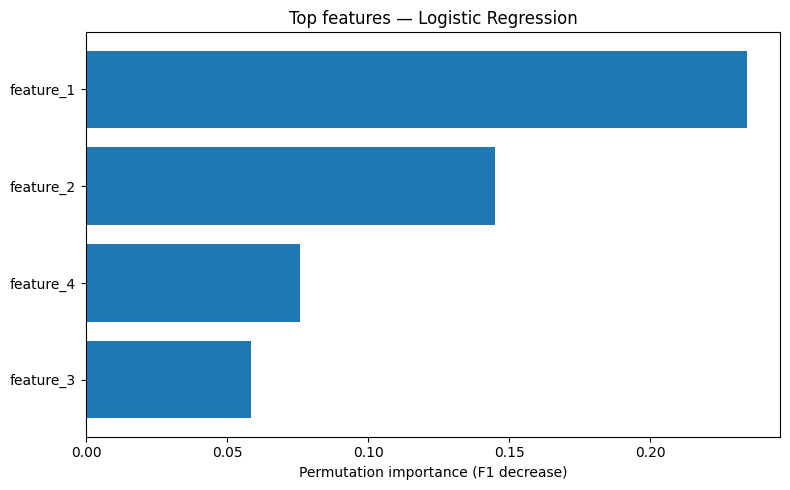

In [9]:
# Permutation importance on the held-out evaluation set.
if best_model is not None:
    perm = permutation_importance(
        best_model, X_test, y_test,
        scoring="f1", n_repeats=10, random_state=RANDOM_STATE
    )
    importance = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    display(importance.round(4))

    top = importance.head(10).sort_values("importance_mean")
    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top["importance_mean"])
    plt.xlabel("Permutation importance (F1 decrease)")
    plt.title(f"Top features — {best_name}")
    plt.tight_layout()
    plt.show()


## 5. Self-check

- [ ] Exact W04 dataset loaded
- [ ] Exact W04 baseline reproduced
- [ ] Same evaluation split used
- [ ] Same primary metric used
- [ ] No tuning on final evaluation labels
- [ ] Group-aware validation used if repeated entities exist
- [ ] Preprocessing is inside pipelines
- [ ] Model-vs-baseline table is present
- [ ] Error examples are inspected
- [ ] Feature interpretation is included
- [ ] Notebook is re-run and saved before committing


## Final conclusion template

After replacing the demo data with the real W04 data, write 3–5 sentences:

> The selected model was **[MODEL]**. On the unchanged W04 evaluation split, its **[PRIMARY METRIC]** was **[MODEL SCORE]**, versus **[BASELINE SCORE]** for the W04 baseline, a change of **[DELTA]**. The main errors were **[ERROR PATTERN]**, while the strongest signals were **[FEATURES]**. The model is preferred because it improves the agreed metric without rewarding complexity alone.
